In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Programing\Python Programing\pythonProject\Student_Ai_Uasage_Analysis\DataSet\ai_assistant_usage_student_life.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

In [3]:
df['SessionDate'] = pd.to_datetime(df['SessionDate'], errors='coerce')
df['UsedAgain'] = df['UsedAgain'].astype(bool)


In [4]:
df.drop_duplicates(inplace=True)


In [5]:
# Remove extreme session lengths
q1 = df['SessionLengthMin'].quantile(0.25)
q3 = df['SessionLengthMin'].quantile(0.75)
iqr = q3 - q1

df = df[(df['SessionLengthMin'] >= q1 - 1.5*iqr) &
        (df['SessionLengthMin'] <= q3 + 1.5*iqr)]


In [6]:
df['Year'] = df['SessionDate'].dt.year
df['Month'] = df['SessionDate'].dt.month
df['DayOfWeek'] = df['SessionDate'].dt.day_name()


In [7]:
df['EngagementScore'] = (
    df['SessionLengthMin'] * 0.5 +
    df['TotalPrompts'] * 0.5
)


In [8]:
df['HighSatisfaction'] = df['SatisfactionRating'] >= 4


In [9]:
df.describe()


,SessionDate,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating,Year,Month,EngagementScore
count,3758,9698.000000,9698.000000,9698.000000,9698.000000,3758.000000,3758.000000,9698.000000
mean,2024-12-22 04:03:19.254922752,18.483973,5.202104,3.479583,3.419705,2024.505056,6.465673,11.843038
min,2024-01-07 00:00:00,0.030000,1.000000,1.000000,1.000000,2024.000000,1.000000,0.515000
25%,2024-06-12 00:00:00,9.442500,2.000000,3.000000,2.600000,2024.000000,3.000000,5.901250
50%,2025-01-01 00:00:00,16.230000,4.000000,4.000000,3.500000,2025.000000,6.000000,10.237500
75%,2025-07-01 00:00:00,25.530000,7.000000,4.000000,4.400000,2025.000000,9.000000,16.387500
max,2025-12-06 00:00:00,52.230000,25.000000,5.000000,5.000000,2025.000000,12.000000,38.165000
std,NaN,11.593925,3.963975,0.991895,1.143487,0.500041,3.465372,7.609823


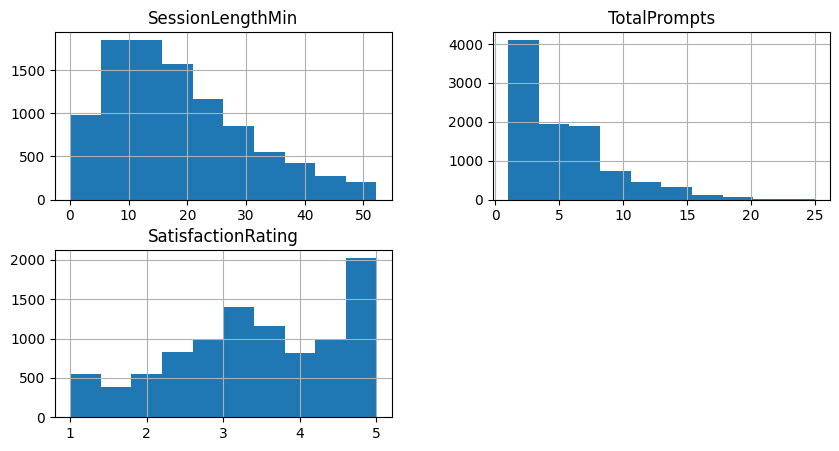

In [10]:
import matplotlib.pyplot as plt

df[['SessionLengthMin', 'TotalPrompts', 'SatisfactionRating']].hist(figsize=(10,5))
plt.show()


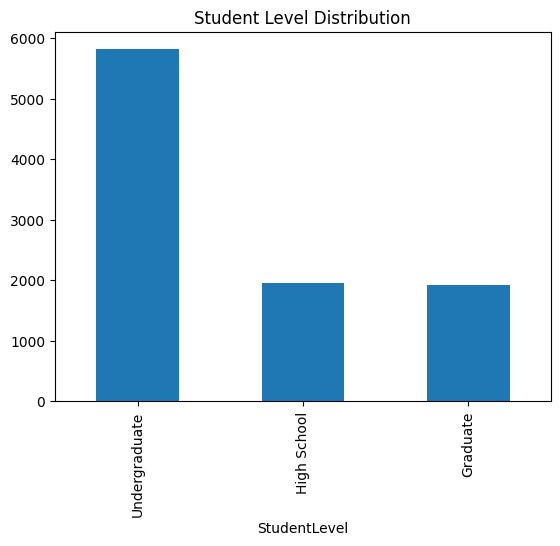

In [11]:
df['StudentLevel'].value_counts().plot(kind='bar')
plt.title("Student Level Distribution")
plt.show()


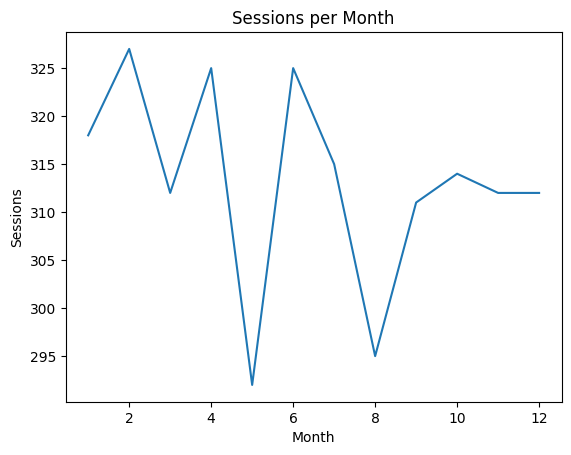

In [13]:
sessions_time = df.groupby('Month').size()

plt.figure()
sessions_time.plot()
plt.title("Sessions per Month")
plt.xlabel("Month")
plt.ylabel("Sessions")
plt.show()



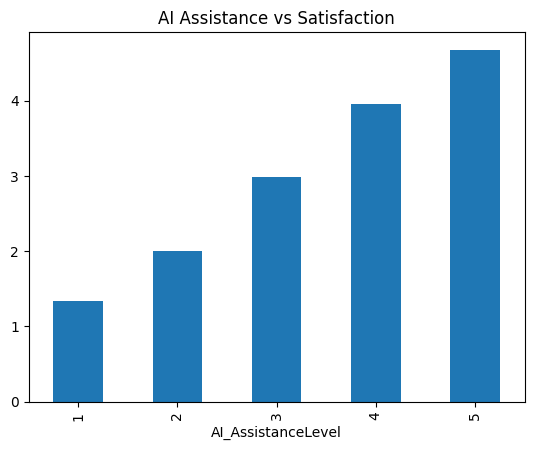

In [14]:
df.groupby('AI_AssistanceLevel')['SatisfactionRating'].mean().plot(kind='bar')
plt.title("AI Assistance vs Satisfaction")
plt.show()


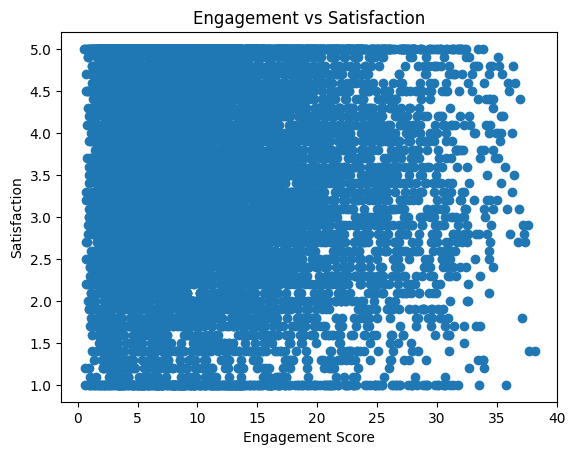

In [15]:
plt.figure()
plt.scatter(df['EngagementScore'], df['SatisfactionRating'])
plt.xlabel("Engagement Score")
plt.ylabel("Satisfaction")
plt.title("Engagement vs Satisfaction")
plt.show()


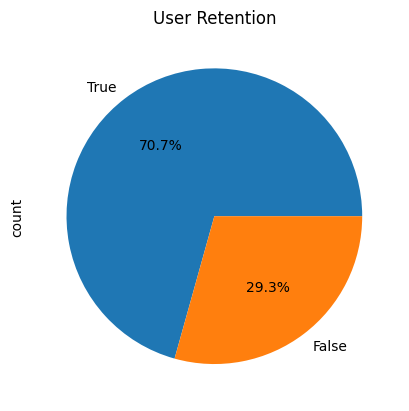

In [16]:
df['UsedAgain'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("User Retention")
plt.show()


In [17]:
from sklearn.preprocessing import LabelEncoder

cols = ['StudentLevel','Discipline','TaskType','FinalOutcome']

encoder = LabelEncoder()
for col in cols:
    df[col] = encoder.fit_transform(df[col])


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9698 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   SessionID           9698 non-null   object        
 1   StudentLevel        9698 non-null   int64         
 2   Discipline          9698 non-null   int64         
 3   SessionDate         3758 non-null   datetime64[ns]
 4   SessionLengthMin    9698 non-null   float64       
 5   TotalPrompts        9698 non-null   int64         
 6   TaskType            9698 non-null   int64         
 7   AI_AssistanceLevel  9698 non-null   int64         
 8   FinalOutcome        9698 non-null   int64         
 9   UsedAgain           9698 non-null   bool          
 10  SatisfactionRating  9698 non-null   float64       
 11  Year                3758 non-null   float64       
 12  Month               3758 non-null   float64       
 13  DayOfWeek           3758 non-null   object        
 1

In [19]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

cat_cols = ['StudentLevel','Discipline','TaskType','FinalOutcome','DayOfWeek']

encoder = LabelEncoder()
for col in cat_cols:
    df_model[col] = encoder.fit_transform(df_model[col])


In [20]:
features = [
    'SessionLengthMin',
    'TotalPrompts',
    'AI_AssistanceLevel',
    'EngagementScore',
    'StudentLevel',
    'Discipline',
    'TaskType',
    'FinalOutcome',
    'Month'
]

X = df_model[features]


In [21]:
y_reg = df_model['SatisfactionRating']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


In [23]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

reg_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)


MAE: 0.6122659278350516
R2 Score: 0.5549856918785252


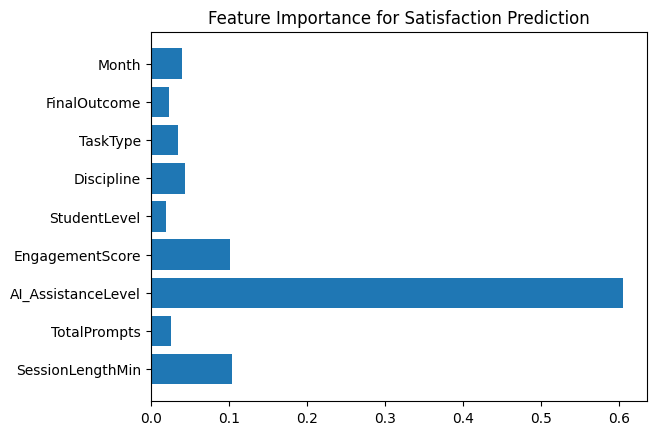

In [25]:


importance = reg_model.feature_importances_
plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance for Satisfaction Prediction")
plt.show()


In [26]:
y_clf = df_model['UsedAgain'].astype(int)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)


In [28]:
from sklearn.ensemble import RandomForestClassifier

clf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

clf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7242268041237113

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.33      0.41       564
           1       0.76      0.89      0.82      1376

    accuracy                           0.72      1940
   macro avg       0.65      0.61      0.61      1940
weighted avg       0.70      0.72      0.70      1940


Confusion Matrix:
 [[ 185  379]
 [ 156 1220]]


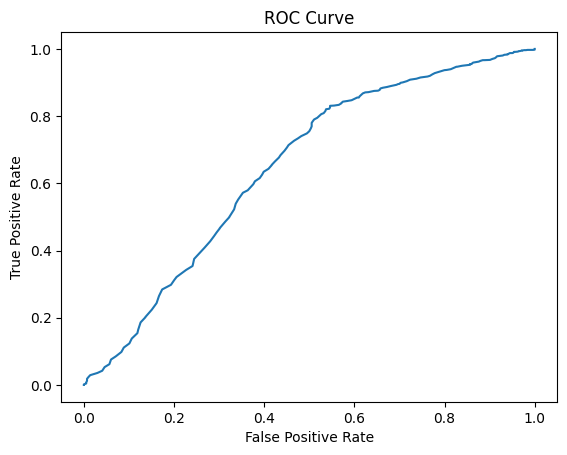

In [30]:
from sklearn.metrics import roc_curve, auc

y_prob = clf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [31]:
sample = X.iloc[0:1]

pred_satisfaction = reg_model.predict(sample)
pred_used_again = clf_model.predict(sample)

print("Predicted Satisfaction:", pred_satisfaction)
print("Will User Return:", pred_used_again)


Predicted Satisfaction: [1.9445]
Will User Return: [1]
